## Import Packages and Libraries

In [43]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, ParameterEstimator
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference.CausalInference import CausalInference

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import daft
from daft import PGM

import sys
import psutil
import os

## Data Cleaning/Preparation

+ Data cleaning: This involves identifying and correcting errors or inconsistencies in the data, such as missing or duplicate values, incorrect data types, and outliers.

+ Data transformation: This involves transforming the data into a format that is suitable for analysis. This may involve converting data types, standardizing units of measurement, and normalizing or scaling the data.

+ Data integration: This involves combining data from multiple sources into a single dataset. This may involve merging data based on a common key or creating new variables based on existing ones.

+ Feature engineering: This involves creating new variables or features based on the existing data to improve the performance of machine learning algorithms. This may involve creating new variables by combining existing ones or transforming variables to improve their predictive power.

Data splitting: This involves splitting the data into training, validation, and testing sets to evaluate the performance of machine learning models.

Data sampling: This involves selecting a representative subset of the data to reduce computation time and improve model performance.

## Graph the BN Model
Graph the Bayesian Network Model using Daft Package

## Prepare the Model in pgmpy
This includes:

+ plugging in CPDs of parent nodes
+ estimating CPDs of the rest of the nodes
+ calculating the likelihood of certain nodes, dependent and independent

## Prepare the Model in pgmpy
This includes:

+ plugging in CPDs of parent nodes
+ estimating CPDs of the rest of the nodes
+ calculating the likelihood of certain nodes, dependent and independent

In [44]:
#importing data
covid = pd.read_excel("symptomatic_dataset.xlsx")
covid.head(2)

,ID,Completion_Date,Age,Gender,Banana,Caramel,Mint,Orange,Pineapple,Vanilla,...,6__Alzheimer,7__Cold,8__Cough,9__Fever,10__Muscular_pain,11__Breathing_difficulty,12__Other_COMMENTS,13__Days_with_symptoms,Smoker,COVI19_PCR
0,1,2020-06-01,30,Female,0,0,1,0,1,1,...,0,1,0,0,0,0,anosmia,3,0,1
1,2,2020-06-01,31,Female,0,1,1,1,0,1,...,0,0,1,0,1,0,NaN,2,0,1


In [45]:
covid.columns

Index(['ID', 'Completion_Date', 'Age', 'Gender', 'Banana', 'Caramel', 'Mint',
       'Orange', 'Pineapple', 'Vanilla', '1__Rinitis_or_Sinusitis',
       '2__Respiratory_allergies', '3__Hypertension', '4__Diabetes',
       '5__Parkinson', '6__Alzheimer', '7__Cold', '8__Cough', '9__Fever',
       '10__Muscular_pain', '11__Breathing_difficulty', '12__Other_COMMENTS',
       '13__Days_with_symptoms', 'Smoker', 'COVI19_PCR'],
      dtype='object')

In [46]:
covid.isna().sum()

#drop columns that are not predictors
dropthis = ["ID","12__Other_COMMENTS", "13__Days_with_symptoms", "Completion_Date"]
covid_symp = covid.drop(dropthis, axis=1)

In [47]:
#Create a mask based on the condition
mask = (covid['Banana'] + covid['Caramel'] + covid['Mint'] + covid['Orange'] + covid['Pineapple'] + covid['Vanilla']) > 3

#Assign the values 1 or 0 to the new column based on the mask
covid['Anosmia'] = mask.astype(int)

We create a new  column that combines the number of pre existing conditions into 1.

In [48]:
covid['under_cond'] = 0

# Check if any of the other columns have a value of 1 for each row
covid['under_cond'] = covid[[ '2__Respiratory_allergies', '3__Hypertension', '4__Diabetes','5__Parkinson','6__Alzheimer']].any(axis=1).astype(int)
covid_symp['under_cond']=covid['under_cond']
#we use the any to check if the four columns if there is a 1, the response we get is true or false and we thus convert it into binary using the astype int

In [49]:
#drop columns that are not predictors
dropthis = ["ID","12__Other_COMMENTS", "Completion_Date",
            "Banana", "Caramel", "Mint", "Orange", "Pineapple", "Vanilla"]
covid_symp = covid.drop(dropthis, axis=1)

Trying to use numbers from 0-4 as the state names fro the given age groups, when we use actual state names I experience an error , trying to resolve this

In [50]:
#Age ranges
age_groups = {
    range(0, 13): 0,
    range(13, 25): 1,
    range(25, 45): 2,
    range(45, 66): 3,
    range(66, 120): 4
}

# encode the age column
covid_symp['Age_group'] = covid_symp['Age'].map(lambda Age: next((a for b, a in age_groups.items() if Age in b), None))
covid['Age_group']=covid_symp['Age_group']
covid['under_cond']=covid_symp['under_cond']

In [51]:
covid_symp = covid_symp.rename(columns={'1__Rinitis_or_Sinusitis': 'RinitisSinusitis',
                        '2__Respiratory_allergies': 'RespiratoryAllegies',
                        '3__Hypertension': 'Hypertension',
                        '4__Diabetes': 'Diabetes',
                        '5__Parkinson': 'Parkinson',
                        '6__Alzheimer': 'Alzheimer',
                        '7__Cold': 'Cold',
                        '8__Cough': 'Cough',
                        '9__Fever': 'Fever',
                        '10__Muscular_pain': 'MuscularPain',
                        '11__Breathing_difficulty': 'Breathingdifficulty',
                        '13__Days_with_symptoms': 'SymptomDays' ,
                                        'under_cond':'undercond'
                       })


covid = covid.rename(columns={'1__Rinitis_or_Sinusitis': 'RinitisSinusitis',
                        '2__Respiratory_allergies': 'RespiratoryAllegies',
                        '3__Hypertension': 'Hypertension',
                        '4__Diabetes': 'Diabetes',
                        '5__Parkinson': 'Parkinson',
                        '6__Alzheimer': 'Alzheimer',
                        '7__Cold': 'Cold',
                        '8__Cough': 'Cough',
                        '9__Fever': 'Fever',
                        '10__Muscular_pain': 'MuscularPain',
                        '11__Breathing_difficulty': 'Breathingdifficulty',
                        '13__Days_with_symptoms': 'SymptomDays' ,
                                        'under_cond':'undercond'
                       })

In [52]:
#checking stats
covid_symp.describe()

,Age,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Parkinson,Alzheimer,Cold,Cough,Fever,MuscularPain,Breathingdifficulty,SymptomDays,Smoker,COVI19_PCR,Anosmia,undercond,Age_group
count,926.000000,926.000000,926.000000,926.000000,926.000000,926.0,926.0,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000
mean,37.293737,0.134989,0.139309,0.095032,0.021598,0.0,0.0,0.338013,0.345572,0.168467,0.371490,0.139309,3.098272,0.281857,0.333693,0.830454,0.235421,2.160907
std,13.073849,0.341897,0.346456,0.293418,0.145446,0.0,0.0,0.473289,0.475812,0.374482,0.483464,0.346456,1.421099,0.450147,0.471786,0.375437,0.424491,0.701369
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,35.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000,0.000000,2.000000
75%,46.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.000000,1.000000,0.000000,1.000000,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,3.000000
max,84.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [53]:
#drop Age: age group, Parkinson and Alzheimer has no variance
dropthis = ["Age", "Parkinson", "Alzheimer"]
covid_symp = covid_symp.drop(dropthis, axis=1)

In [54]:
pd.Categorical(covid['Gender']).describe()

,counts,freqs
categories,,
Female,445,0.480562
Masculine,481,0.519438


In [55]:
#defining features and target
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = covid_symp.drop(columns=[target]).columns.tolist()
features

['Gender',
 'RinitisSinusitis',
 'RespiratoryAllegies',
 'Hypertension',
 'Diabetes',
 'Cold',
 'Cough',
 'Fever',
 'MuscularPain',
 'Breathingdifficulty',
 'SymptomDays',
 'Smoker',
 'Anosmia',
 'undercond',
 'Age_group']

In [56]:
covid_symp.head()

,Gender,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Cold,Cough,Fever,MuscularPain,Breathingdifficulty,SymptomDays,Smoker,COVI19_PCR,Anosmia,undercond,Age_group
0,Female,0,0,0,0,1,0,0,0,0,3,0,1,0,0,2
1,Female,0,0,0,0,0,1,0,1,0,2,0,1,1,0,2
2,Female,1,0,0,0,1,0,0,1,0,3,0,1,1,0,2
3,Female,0,0,0,0,1,1,1,1,0,2,0,1,0,0,2
4,Masculine,0,0,0,0,1,1,1,0,0,2,0,1,0,0,2


In [57]:
bnmodel = BayesianNetwork([('Age_group','undercond'),
                     ('Age_group','MuscularPain'),('Breathingdifficulty', 'COVI19_PCR'),('MuscularPain', 'COVI19_PCR'), ('Fever', 'COVI19_PCR'),
                           ('Cough', 'COVI19_PCR'),( 'RinitisSinusitis','Anosmia'),('Anosmia','COVI19_PCR'),('undercond','COVI19_PCR'),('Cold','Cough'),('Cold','Fever'),('Smoker', 'undercond')
                       
                        
                       ])

#('6__Alzheimer','COVI19_PCR')
#,('5__Parkinson','COVI19_PCR'),('Age_g','5__Parkinson')



In [58]:
#age_groups = ['0-12', '13-24', '25-44', '45-65', '66+']
Age_cpd = TabularCPD(variable='Age_group',
                      variable_card=5,
                      values=[[.17], [.135],[.282],[.242],[.171]])


#Age_cpd.state_names = {'Age_group': age_groups}
#Alzheimer_cpd = TabularCPD(variable='6__Alzheimer',
                      #variable_card=2,
                      #values=[[.2], [.8]])
#Respiratory_allergies_cpd = TabularCPD(variable='2__Respiratory_allergies',
                       #variable_card=2,
                       #values=[[.2], [.8]])
Rinitis_or_Sinusitis_cpd = TabularCPD(variable='RinitisSinusitis',
                      variable_card=2,
                       values=[[0.16], [.84]])

#Gender_cpd = TabularCPD(variable='Gender',
                    # variable_card=2,
                      #values=[[.506],[.494]])
Smoker_cpd = TabularCPD(variable='Smoker',
                       variable_card=2,
                       values=[[.907], [.093]])
Cold_cpd = TabularCPD(variable='Cold',
                       variable_card=2,
                       values=[[.2], [.8]])

Breathing_difficulty_cpd = TabularCPD(variable='Breathingdifficulty',
                       variable_card=2,
                       values=[[.579], [.421]])


Anosmia_cpd = TabularCPD(variable='Anosmia',
                       variable_card=2,
                       values=[[0.7,.618], [0.3,.382]],
                       evidence=['RinitisSinusitis'], evidence_card=[2])
#MPcpd = TabularCPD(variable='MuscularPain',
                       #variable_card=2,
                       #values=[[0.19,0.19,0.26,0.26,0.26], [0.81,0.81,0.74,0.74,0.74]],
                       #evidence=['Age_group'], evidence_card=[5])
#MPcpd.state_names = {'Age_group': age_groups}


#Hypertension_cpd = TabularCPD(variable='3__Hypertension',
#                       variable_card=2,
#                       values=[[.2], [.8]])
#Diabetes_cpd = TabularCPD(variable='4__Diabetes',
#                       variable_card=2,
#                       values=[[.2], [.8]])
#Parkinson_cpd = TabularCPD(variable='5__Parkinson',
                      #variable_card=2,
                      #values=[[.2], [.8]])



        #Cough_cpd = TabularCPD(variable='8__Cough',
                       #variable_card=2,
                       #values=[[.32], [.68]])

#Fever_cpd = TabularCPD(variable='9__Fever',
                       #variable_card=2,
                       #values=[[.175], [.825]])
#
#Muscular_pain_cpd = TabularCPD(variable='10__Muscular_pain',
                       #variable_card=2,
                       #values=[[.774], [.226]])
#


print(Age_cpd.state_names)

{'Age_group': [0, 1, 2, 3, 4]}


In [59]:
bnmodel.add_cpds(Age_cpd, Rinitis_or_Sinusitis_cpd,Smoker_cpd, Cold_cpd, Breathing_difficulty_cpd, Anosmia_cpd)
#bnmodel.get_cpds('Age_group').state_names = {'Age_group': ['0-12', '13-24', '25-44', '45-65', '66+']}
#Age_cpd = TabularCPD(variable='Age_group',
                      #variable_card=5,
                      #values=[[.17], [.135],[.282],[.242],[.171]])
#bnmodel.add_cpds(Age_cpd)

from sklearn.model_selection import train_test_split

# Assuming your dataset is stored in 'data' (including both features and target variable)

# Split the dataset into train and test sets
training_data, testing_data = train_test_split(covid, test_size=0.35, random_state=42)



mle = BayesianEstimator(bnmodel, training_data)

#mle = MaximumLikelihoodEstimator(bnmodel, covid)

covid_cpd = mle.estimate_cpd('COVI19_PCR')
cough_cpd = mle.estimate_cpd('Cough')
fever_cpd = mle.estimate_cpd('Fever')

mascu_cpd = mle.estimate_cpd('MuscularPain')
undercond_cpd = mle.estimate_cpd('undercond')
print(mascu_cpd)
print(undercond_cpd)

bnmodel.add_cpds(cough_cpd,fever_cpd,undercond_cpd,mascu_cpd,covid_cpd)


+-----------------+--------------------+--------------------+--------------+--------------+--------------+
| Age_group       | Age_group(0)       | Age_group(1)       | Age_group(2) | Age_group(3) | Age_group(4) |
+-----------------+--------------------+--------------------+--------------+--------------+--------------+
| MuscularPain(0) | 0.4166666666666667 | 0.4722222222222222 | 0.5          | 0.5625       | 0.375        |
+-----------------+--------------------+--------------------+--------------+--------------+--------------+
| MuscularPain(1) | 0.5833333333333334 | 0.5277777777777778 | 0.5          | 0.4375       | 0.625        |
+-----------------+--------------------+--------------------+--------------+--------------+--------------+
+--------------+--------------+---------------------+-----+---------------------+--------------+
| Age_group    | Age_group(0) | Age_group(0)        | ... | Age_group(4)        | Age_group(4) |
+--------------+--------------+---------------------+----

<Axes:>

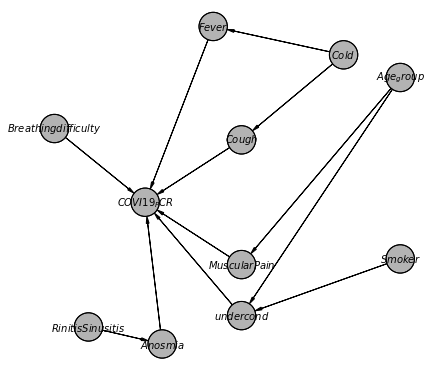

In [60]:
bnmodel.to_daft(node_pos={"Anosmia": (3.3,1),
                          "RinitisSinusitis": (2, 1.3),
                          
                          "undercond": (4.7,1.5),
                          #"Alzheimer": (1,4),
                          "Breathingdifficulty": (1.4,4.8),
                          #"SymptomDays": (2,5.5),
                          #"RespiratoryAllegies": (3,6),
                          "COVI19_PCR": (3,3.5),
                          "Smoker": (7.5,2.5),
                          "MuscularPain": (4.7,2.4),
                          #"Parkinson": (5.1, 3.5),
                          "Cough": (4.7,4.6),
                          "Fever": (4.2,6.6),
                          "Cold": (6.5,6.1),
                          "Age_group": (7.5,5.7),
                          #"Gender": (6.5,1.5)                         
                         }
               ).render()

In [61]:
is_valid =bnmodel.check_model()
if is_valid:
    print("The model is valid.")
else:
    print("The model is invalid.")
    
cpds = bnmodel.get_cpds()
for cpd in cpds:
    print(cpd)    

The model is valid.
+--------------+-------+
| Age_group(0) | 0.17  |
+--------------+-------+
| Age_group(1) | 0.135 |
+--------------+-------+
| Age_group(2) | 0.282 |
+--------------+-------+
| Age_group(3) | 0.242 |
+--------------+-------+
| Age_group(4) | 0.171 |
+--------------+-------+
+---------------------+------+
| RinitisSinusitis(0) | 0.16 |
+---------------------+------+
| RinitisSinusitis(1) | 0.84 |
+---------------------+------+
+-----------+-------+
| Smoker(0) | 0.907 |
+-----------+-------+
| Smoker(1) | 0.093 |
+-----------+-------+
+---------+-----+
| Cold(0) | 0.2 |
+---------+-----+
| Cold(1) | 0.8 |
+---------+-----+
+------------------------+-------+
| Breathingdifficulty(0) | 0.579 |
+------------------------+-------+
| Breathingdifficulty(1) | 0.421 |
+------------------------+-------+
+------------------+---------------------+---------------------+
| RinitisSinusitis | RinitisSinusitis(0) | RinitisSinusitis(1) |
+------------------+---------------------+---

In [62]:
target = 'COVI19_PCR'
# Define features as all columns except the target variable
features = covid_symp.drop(columns=[target])
# Define target variable
target = covid_symp[target]

In [63]:
covid_symp['Age_group'].unique()

array([2, 3, 0, 1, 4], dtype=int64)

In [64]:
infer=VariableElimination(bnmodel)

In [65]:
evidence = {'Smoker': 0, 'Age_group': 3, 'Fever': 0, 'Cough':0} #0 is true
print(infer.query(['COVI19_PCR'], evidence=evidence))

+---------------+-------------------+
| COVI19_PCR    |   phi(COVI19_PCR) |
+===============+===================+
| COVI19_PCR(0) |            0.6953 |
+---------------+-------------------+
| COVI19_PCR(1) |            0.3047 |
+---------------+-------------------+


In [66]:
covidne=covid[['Age_group', 'undercond', 'MuscularPain', 'Breathingdifficulty', 'COVI19_PCR', 'Fever', 'Cough', 'RinitisSinusitis', 'Anosmia', 'Cold', 'Smoker']]

#defining features and target
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = covidne.drop(columns=[target]).columns.tolist()

In [67]:
# Split the data into training and testing set using 10-fold stratified sampling
from sklearn.model_selection import train_test_split

# Assuming your dataset is stored in 'X' (features) and 'y' (target variable)

# Split the dataset into training and testing sets
X_valid, X_test, y_valid, y_test = train_test_split(testing_data[features], testing_data[target], test_size=0.2, random_state=42)

In [68]:
inference = VariableElimination(bnmodel)
predictions = []
for i in range(len(X_valid)):
    evidence = X_valid.iloc[i].to_dict()
    query = 'COVI19_PCR'
    factor = inference.query([query], evidence=evidence)
    prediction = factor.values[0]
    predictions.append(prediction)
# setting up the threshold value such that, we start with a threshold of 0.5
    
newpred=[]
for i in range(len(predictions)):
    if predictions[i]>=0.5:
        newpred.append(1)
    else:
        newpred.append(0)


In [69]:
# setting up the threshold value such that, we start with a threshold of 0.5
from sklearn.metrics import confusion_matrix

# Assuming you ha]ve the true labels and predicted labels
true_labels = y_valid
predicted_labels = newpred

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

print(cm)


# Extracting the values from the confusion matrix
TN, FP, FN, TP = cm.ravel()

# Calculating accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)


[[ 15 155]
 [ 23  67]]
Accuracy: 0.3153846153846154


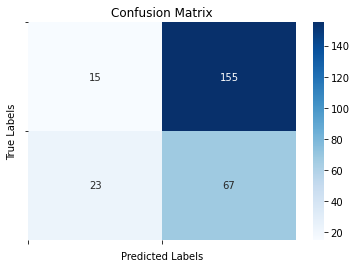

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create a heatmap using seaborn
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# Set labels, title, and axis ticks
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.xticks([0, 1])  # Set x-axis tick locations
plt.yticks([0, 1])  # Set y-axis tick locations

# Display the plot
plt.show()


In [71]:
inference = VariableElimination(bnmodel)
predictions = []
for i in range(len(X_test)):
    evidence = X_test.iloc[i].to_dict()
    query = 'COVI19_PCR'
    factor = inference.query([query], evidence=evidence)
    prediction = factor.values[0]
    predictions.append(prediction)
# setting up the threshold value such that, we start with a threshold of 0.5
    
newpred1=[]
for i in range(len(predictions)):
    if predictions[i]>=0.5:
        newpred1.append(1)
    else:
        newpred1.append(0)
        
print(len(newpred1))
len(y_test)

65


65

In [72]:
# Assuming you ha]ve the true labels and predicted labels
true_labels = y_test
predicted_labels = newpred1

# Create the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

print(cm)


# Extracting the values from the confusion matrix
TN, FP, FN, TP = cm.ravel()

# Calculating accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Accuracy:", accuracy)


[[ 5 41]
 [ 6 13]]
Accuracy: 0.27692307692307694


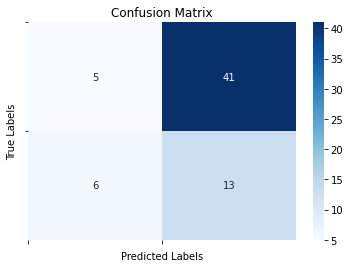

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create a heatmap using seaborn
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# Set labels, title, and axis ticks
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.xticks([0, 1])  # Set x-axis tick locations
plt.yticks([0, 1])  # Set y-axis tick locations

# Display the plot
plt.show()

In [74]:
# Initialize a 10-fold stratified sampling
skf = StratifiedKFold(n_splits=10)

In [75]:

covid_pe = ParameterEstimator(bnmodel, covid)
#print("\n", covid_pe.state_counts('Age'))  # unconditional
#print("\n", covid_pe.state_counts('COVID19_PCR'))  # conditional on fruit and size

In [76]:
# Calibrate all CPDs of `model` using MLE:
bnmodel.fit(covid, estimator=MaximumLikelihoodEstimator)

In [77]:
est = BayesianEstimator(bnmodel, covid)

print(est.estimate_cpd('COVI19_PCR', prior_type='BDeu', equivalent_sample_size=10))

+---------------------+------------------------+-----+------------------------+------------------------+
| Anosmia             | Anosmia(0)             | ... | Anosmia(1)             | Anosmia(1)             |
+---------------------+------------------------+-----+------------------------+------------------------+
| Breathingdifficulty | Breathingdifficulty(0) | ... | Breathingdifficulty(1) | Breathingdifficulty(1) |
+---------------------+------------------------+-----+------------------------+------------------------+
| Cough               | Cough(0)               | ... | Cough(1)               | Cough(1)               |
+---------------------+------------------------+-----+------------------------+------------------------+
| Fever               | Fever(0)               | ... | Fever(1)               | Fever(1)               |
+---------------------+------------------------+-----+------------------------+------------------------+
| MuscularPain        | MuscularPain(0)        | ... | 

In [78]:
# generate data
bnmodel.fit(covid, estimator=BayesianEstimator, prior_type="BDeu") # default equivalent_sample_size=5
for cpd in bnmodel.get_cpds():
    print(cpd)

+--------------+-----------+
| Age_group(0) | 0.0258303 |
+--------------+-----------+
| Age_group(1) | 0.0922509 |
+--------------+-----------+
| Age_group(2) | 0.656827  |
+--------------+-----------+
| Age_group(3) | 0.206642  |
+--------------+-----------+
| Age_group(4) | 0.0184502 |
+--------------+-----------+
+---------------------+----------+
| RinitisSinusitis(0) | 0.854244 |
+---------------------+----------+
| RinitisSinusitis(1) | 0.145756 |
+---------------------+----------+
+-----------+----------+
| Smoker(0) | 0.728782 |
+-----------+----------+
| Smoker(1) | 0.271218 |
+-----------+----------+
+---------+----------+
| Cold(0) | 0.651292 |
+---------+----------+
| Cold(1) | 0.348708 |
+---------+----------+
+------------------------+----------+
| Breathingdifficulty(0) | 0.802583 |
+------------------------+----------+
| Breathingdifficulty(1) | 0.197417 |
+------------------------+----------+
+------------------+---------------------+---------------------+
| RinitisSi

In [79]:
covid_symp.head(1)

,Gender,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Cold,Cough,Fever,MuscularPain,Breathingdifficulty,SymptomDays,Smoker,COVI19_PCR,Anosmia,undercond,Age_group
0,Female,0,0,0,0,1,0,0,0,0,3,0,1,0,0,2


In [80]:
evidence = {'Smoker': 0, 'Age_group': 4, 'Fever': 1}
print(infer.query(['COVI19_PCR'], evidence=evidence))

+---------------+-------------------+
| COVI19_PCR    |   phi(COVI19_PCR) |
+===============+===================+
| COVI19_PCR(0) |            0.4184 |
+---------------+-------------------+
| COVI19_PCR(1) |            0.5816 |
+---------------+-------------------+


In [81]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Set the number of splits (k)
k = 5
totac=[]
# Initialize StratifiedKFold
stratified_kfold = StratifiedKFold(n_splits=k, shuffle=True)

# Perform k-stratified sampling
for train_index, test_index in stratified_kfold.split(covidne.iloc[:, :-1], covidne.iloc[:, -1]):
    train_data, test_data = covidne.iloc[train_index], covidne.iloc[test_index]
    #creating the model
    bnmodel = BayesianNetwork([('Age_group','undercond'),
                     ('Age_group','MuscularPain'),('Breathingdifficulty', 'COVI19_PCR'),('MuscularPain', 'COVI19_PCR'), ('Fever', 'COVI19_PCR'),
                           ('Cough', 'COVI19_PCR'),( 'RinitisSinusitis','Anosmia'),('Anosmia','COVI19_PCR'),('undercond','COVI19_PCR'),('Cold','Cough'),('Cold','Fever'),('Smoker', 'undercond')
                       
                        
                       ])
    
    bnmodel.add_cpds(Age_cpd, Rinitis_or_Sinusitis_cpd,Smoker_cpd, Cold_cpd, Breathing_difficulty_cpd, Anosmia_cpd)
    #training the model
    mle = BayesianEstimator(bnmodel, train_data)
    covid_cpd = mle.estimate_cpd('COVI19_PCR')
    cough_cpd = mle.estimate_cpd('Cough')
    fever_cpd = mle.estimate_cpd('Fever')
    mascu_cpd = mle.estimate_cpd('MuscularPain')
    undercond_cpd = mle.estimate_cpd('undercond')
    bnmodel.add_cpds(cough_cpd,fever_cpd,undercond_cpd,mascu_cpd,covid_cpd)

    
    
    
    infer=VariableElimination(bnmodel)
    #defining features and target
    target = "COVI19_PCR"
    # Define features as all columns except the target variable
    features = covidne.drop(columns=[target]).columns.tolist()
    X_valid, X_test, y_valid, y_test = train_test_split(test_data[features], test_data[target], test_size=0.35, random_state=42)
    
    inference = VariableElimination(bnmodel)
    predictions = []
    for i in range(len(X_valid)):
        evidence = X_valid.iloc[i].to_dict()
        query = 'COVI19_PCR'
        factor = inference.query([query], evidence=evidence)
        prediction = factor.values[0]
        predictions.append(prediction)
# setting up the threshold value such that, we start with a threshold of 0.5
    
    newpred=[]
    for i in range(len(predictions)):
        if predictions[i]>=0.30:
            newpred.append(1)
        else:
                newpred.append(0)
                
    # setting up the threshold value such that, we start with a threshold of 0.5
    from sklearn.metrics import confusion_matrix
    true_labels = y_valid
    predicted_labels = newpred
    cm = confusion_matrix(true_labels, predicted_labels)
    print(cm)
    # Extracting the values from the confusion matrix
    TN, FP, FN, TP = cm.ravel()
    # Calculating accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    print("Accuracy:", accuracy)
    totac.append(accuracy)

print("Average accuracy:", np.mean(totac))


[[ 3 77]
 [ 6 34]]
Accuracy: 0.30833333333333335
[[ 6 79]
 [ 2 33]]
Accuracy: 0.325
[[ 6 72]
 [11 31]]
Accuracy: 0.30833333333333335
[[ 2 76]
 [13 29]]
Accuracy: 0.25833333333333336
[[ 4 83]
 [10 23]]
Accuracy: 0.225
Average accuracy: 0.28500000000000003


In [82]:
# get the system's virtual memory
vm = psutil.virtual_memory()

# print the total, available, and used memory in the system
print(f"Total memory: {vm.total/(1024*1024*1024):.2f} GB")
print(f"Available memory: {vm.available/(1024*1024*1024):.2f} GB")
print(f"Used memory: {vm.used/(1024*1024*1024):.2f} GB")

Total memory: 6.96 GB
Available memory: 0.83 GB
Used memory: 6.13 GB
